In [5]:
from IPython.display import HTML
html_content = """<link rel="stylesheet" type="text/css" href="style.css">"""
display(HTML(html_content))

In [4]:
import plotly.io as pio
# Imposta il renderer per includere il codice JavaScript necessario
pio.renderers.default = "notebook_connected"

<div style="border:1px solid #d9e2ec; border-radius:18px; padding:28px 30px; background:linear-gradient(180deg, #ffffff 0%, #f8fbff 100%); box-shadow:0 10px 28px rgba(15, 23, 42, 0.08); text-align:center;">
  <h3 style="margin:0; color:#1f2937; font-size:1.35em; font-weight:600;">Andrea Plai</h3>
  <p style="margin:4px 0 18px 0; color:#6b7280; font-size:0.95em;">Matricola 167223</p>
  <h2 style="margin:0; color:#111827; font-size:2.2em; line-height:1.15;"><b>Fondamenti Di Scienza Dei Dati<br>E Laboratorio</b></h2>
  <div style="margin-top:18px; display:grid; gap:10px;">
    <p style="margin:0; color:#374151; font-size:1.02em;"><strong>Modulo:</strong> Presentazione del progetto</p>
    <p style="margin:0; color:#374151; font-size:1.02em;"><strong>Titolo:</strong> <span style="color:#b91c1c; font-weight:700;">Riscaldamento globale: Evoluzione della temperatura terrestre</span></p>
  </div>
  <p style="margin:22px 0 0 0; color:#6b7280;">Premi <button>Esc</button> in qualsiasi momento per vedere la mappa di navigazione</p>
</div>

<div style=" border-radius:14px; padding:18px 20px; background:#ffffff; box-shadow:0 6px 18px rgba(15, 23, 42, 0.06);">
  <h2 style="margin:0 0 10px 0; color:#111827;">1. Radici del progetto</h2>
  <h3 style="margin:0 0 10px 0; color:#374151;">Motivazioni della ricerca</h3>
  <ul style="margin:0; padding-left:22px; color:#374151; line-height:1.7;">
    <li>Interesse personale</li>
    <li>Rilevanza attuale</li>
  </ul>
</div>

<div style="border:1px solid #e5e7eb; border-radius:14px; padding:18px 20px; background:linear-gradient(180deg, #ffffff 0%, #fbfdff 100%);">
  <h2 style="margin:0 0 10px 0; color:#111827;">2. Descrizione dei dati</h2>
  <p style="margin:0 0 12px 0; color:#374151; line-height:1.7;">Dati di 3448 città ottenuti dal 1743 al 2013 con le seguenti informazioni:</p>
  <ul style="margin:0 0 12px 0; padding-left:22px; color:#374151; line-height:1.7;">
    <li>Temperatura media</li>
    <li>Latiudine e longitudine</li>
    <li>Paese di appartenenza</li>
  </ul>
  <p style="margin:0; color:#6b7280; line-height:1.7;"><strong>Fonte:</strong> <strong style="color:#2563eb;">Kaggle</strong> - <a href="https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data" style="color:#2563eb; font-weight:600; text-decoration:none;">Berkeley Earth Surface Temperature Data</a></p>
</div>

<div class="card" style="border:1px solid #e5e7eb; border-radius:12px; padding:16px; background:#ffffff;">
  <h2 style="margin:0 0 8px 0; color:#111827; font-size:1.05em;">Dataset città</h2>
  <p style="margin:0 0 8px 0; color:#374151;">Informazioni principali disponibili per ogni città:</p>
  <ul style="margin:0 0 8px 0; padding-left:20px; color:#374151; line-height:1.6;">
    <li>Popolazione</li>
    <li>Longitudine e latitudine</li>
    <li>Paese di appartenenza</li>
  </ul>
  <p style="margin:0; color:#6b7280;"><strong>Fonte:</strong> <strong style="color:#2563eb;">SimpleMaps</strong> - <a href="https://simplemaps.com/data/world-cities" style="color:#2563eb; font-weight:600; text-decoration:none;">World Cities Database</a></p>
</div>

<div class="card" style="border-left:5px solid #ffffff; border-radius:12px; padding:14px 16px; background:#ffffff;">
  <h3 style="margin:0 0 8px 0; color:#1f2937;">Campione parziale del dataset 📊</h3>
  <p style="margin:0 0 8px 0; color:#374151;">Il dataset finale è stato ottenuto unendo i due dataset citati precedentemente . </p>
  <p style="margin:0; color:#b91c1c; font-weight:600;">Attenzione: colonne omesse per chiarezza esemplificativa.</p>
</div>

In [1]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# 1. Caricamento dei dataset
df_clima = pd.read_csv('Dataset/GlobalLandTemperaturesByCity.csv')
df_città = pd.read_csv('Dataset/worldcities.csv')

# 2. Normalizzazione delle informazioni temporali e spaziali
# Estraiamo l'anno dalla colonna data per lavorare su aggregazioni annuali.
df_clima['Year'] = pd.to_datetime(df_clima['dt']).dt.year

# Conversione delle coordinate da formato testuale a numerico.
def convert_coord(coord_str):
    if pd.isna(coord_str):
        return np.nan
    value = float(coord_str[:-1])
    if coord_str[-1] in ['S', 'W']:
        value = -value
    return value

df_clima['Lat_Num'] = df_clima['Latitude'].apply(convert_coord)
df_clima['Lon_Num'] = df_clima['Longitude'].apply(convert_coord)

# 3. Aggregazione annuale del dataset climatico
# La media per anno riduce la stagionalità e rende il dataset confrontabile nel tempo.
df_annuale = (
    df_clima
    .groupby(['City', 'Country', 'Year'])
    .agg(
        AverageTemperature=('AverageTemperature', 'mean'),
        Lat_Num=('Lat_Num', 'first'),
        Lon_Num=('Lon_Num', 'first')
    )
    .reset_index()
    .dropna(subset=['AverageTemperature'])
)

# 4. Pulizia dei nomi delle città per un merge robusto
df_annuale['city_clean'] = df_annuale['City'].astype(str).str.strip().str.lower()
df_città['city_clean'] = df_città['city'].astype(str).str.strip().str.lower()

# 5. Merge principale basato sul nome della città
uniti = pd.merge(
    df_annuale,
    df_città[['city_clean', 'lat', 'lng', 'population']],
    on='city_clean',
    how='left'
 )

# 6. Fallback spaziale per i record senza corrispondenza nominale
pop_mancante = uniti['population'].isna()

if pop_mancante.any():
    # Per i casi non risolti dal nome, associamo la città geograficamente più vicina.
    città_spaziali = df_città.dropna(subset=['lat', 'lng', 'population'])
    albero = cKDTree(città_spaziali[['lat', 'lng']].values)

    punti_da_matching = uniti.loc[pop_mancante, ['Lat_Num', 'Lon_Num']].fillna(0).values
    _, indici = albero.query(punti_da_matching, k=1)

    uniti.loc[pop_mancante, 'population'] = città_spaziali.iloc[indici]['population'].values

# 7. Pulizia finale del dataframe di lavoro
uniti = uniti.drop(columns=['city_clean'])

display(uniti[['City', 'Country', 'Year', 'AverageTemperature', 'population']].sample(5))

,City,Country,Year,AverageTemperature,population
337231,Ipswich,United Kingdom,1809,8.993250,232930.0
924712,Zielona Gora,Poland,1869,8.759833,16063.0
833674,Trabzon,Turkey,1823,10.321667,293661.0
854680,Valencia,Venezuela,1939,25.437583,1595000.0
441886,Lincoln,United States,1880,9.987417,51629.0


<div style="border:1px solid #e5e7eb; border-radius:14px; padding:18px 20px; background:linear-gradient(180deg, #ffffff 0%, #fbfdff 100%);">
  <h2 style="margin:0 0 10px 0; color:#111827;">3. Analisi effettuata</h2>
  <h3 style="margin:0 0 10px 0; color:#374151;">Indice</h3>
  <ul style="margin:0; padding-left:22px; color:#374151; line-height:1.7;">
    <li>3.1 Come è cambiata la temperatura media annuale nelle diverse fasce di latitudine?</li>
    <li>3.2 La stagionalità è cambiata nel tempo?</li>
    <li>3.3 Quale tipologia di città ha avuto il maggior aumento di temperatura?</li>
    <li>3.4 C'è stato un punto di rottura in cui il sistema ha smesso di compensarsi?</li>
  </ul>
</div>

<div style="border-left:5px solid #2563eb; border-radius:14px; padding:18px 20px; background:#ffffff; box-shadow:0 6px 18px rgba(15, 23, 42, 0.06);">
  <h2 style="margin:0 0 10px 0; color:#111827;">3.1 Fasce Latitudinali</h2>
  <p style="margin:0; color:#374151; line-height:1.7;">Le fasce <i>polare</i> e <i>temperata</i> stanno aumentando di oltre 1°C per secolo <strong>(1.07 e 1.06 rispettivamente)</strong>, mentre i <i>tropici</i> si scaldano più lentamente, a circa <strong>0.8°C per secolo</strong>.</p>
</div>

In [ ]:
import statsmodels.api as sm
import plotly.express as px

# Definizione delle fasce di latitudine
def assign_lat_band(lat):
    lat = abs(lat)
    if lat <= 23.5: return 'Tropicale'
    elif lat <= 66.5: return 'Temperata'
    else: return 'Polare'

uniti['Fascia_Lat'] = uniti['Lat_Num'].apply(assign_lat_band)

# Aggregazione annuale per fascia
trend_lat = uniti.groupby(['Year', 'Fascia_Lat'])['AverageTemperature'].mean().reset_index()

# Filtro 1850
trend_lat = trend_lat[trend_lat['Year'] >= 1850]

# ANALISI STATISTICA (Regressione OLS) 
results = []
for band in trend_lat['Fascia_Lat'].unique():
    subset = trend_lat[trend_lat['Fascia_Lat'] == band]
    X = sm.add_constant(subset['Year'])
    model = sm.OLS(subset['AverageTemperature'], X).fit()
    
    results.append({
        'Fascia': band,
        'Pendenza (Slope)': model.params['Year'],
        'p-value': model.pvalues['Year'],
        'R-squared': model.rsquared
    })

results_df = pd.DataFrame(results)

#  Creazione dello Small Multiples interattivo
fig = px.scatter(
    trend_lat,
    x="Year",
    y="AverageTemperature",
    facet_col="Fascia_Lat", 
    color="Fascia_Lat",     
    trendline="ols",      
    opacity=0.6,          
    facet_col_spacing=0.07,
    title="<b>Trend delle Temperature dal 1850</b>",
    labels={
        "Year": "Anno", 
        "AverageTemperature": "Temperatura Media (°C)"
    }
)

# Rendi gli assi Y indipendenti
fig.update_yaxes(matches=None, showticklabels=True, dtick=0.5)

# Pulisce i titoli dei pannelli
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

# --- FIX LAYOUT PER LE SLIDE ---
fig.update_layout(
    template="plotly_white", 
    showlegend=False,        
    height=400,          
    width=1000,           
    autosize=True,        
    margin=dict(l=20, r=20, t=80, b=40),
    hovermode="closest"
)

# Mostriamo il grafico responsivo
fig.show(config={'responsive': True})

<div style="border-left:5px solid #0f766e; border-radius:14px; padding:18px 20px; background:#ffffff; box-shadow:0 6px 18px rgba(15, 23, 42, 0.06);">
  <h2 style="margin:0; color:#111827;">3.2 Stagionalità</h2>
  <p style="margin:0; color:#374151; line-height:1.7;"><i>L'emisfero Nord</i> ha registrato una diminuzione dell'ampiezza stagionale media, a differenza dell'<i>Emisfero Sud</i>, che è rimasta costante.</p>
</div>


In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

# Analisi della stagionalita per emisfero
df_stagioni = df_clima[df_clima['Year'] >= 1850].copy()
df_stagioni["dt"] = pd.to_datetime(df_stagioni["dt"])
df_stagioni['Hemisphere'] = np.where(df_stagioni['Lat_Num'] >= 0, 'Emisfero Nord', 'Emisfero Sud')
df_stagioni['Month'] = df_stagioni['dt'].dt.month

# Media mensile per anno ed emisfero
ciclo_mensile = (
    df_stagioni
    .groupby(['Year', 'Hemisphere', 'Month'])['AverageTemperature']
    .mean()
    .reset_index()
)

# Ampiezza stagionale annuale: differenza tra mese piu caldo e mese piu freddo
stagionalità = (
    ciclo_mensile
    .groupby(['Year', 'Hemisphere'])['AverageTemperature']
    .agg(['max', 'min'])
    .reset_index()
)
stagionalità['Ampiezza_stagionale'] = stagionalità['max'] - stagionalità['min']

# Media mobile per rendere piu leggibile il trend di lungo periodo
stagionalità['Ampiezza_media_mobile_10a'] = (
    stagionalità
    .groupby('Hemisphere')['Ampiezza_stagionale']
    .transform(lambda s: s.rolling(window=10, center=True, min_periods=1).mean())
)

fig = px.line(
    stagionalità,
    x='Year',
    y='Ampiezza_media_mobile_10a',
    color='Hemisphere',
    title='<b>La stagionalita e cambiata in modo diverso tra emisfero nord e sud?</b></sup>',
    labels={
        'Year': 'Anno',
        'Ampiezza_media_mobile_10a': 'Ampiezza stagionale media mobile (°C)',
        'Hemisphere': 'Emisfero'
    }
)

# Aggiungo i valori annui grezzi in trasparenza per confrontare trend e variabilita
for hemisphere in stagionalità['Hemisphere'].unique():
    sottoinsieme_emisfero = stagionalità[stagionalità['Hemisphere'] == hemisphere]
    fig.add_scatter(
        x=sottoinsieme_emisfero['Year'],
        y=sottoinsieme_emisfero['Ampiezza_stagionale'],
        mode='lines',
        line=dict(width=1),
        opacity=0.18,
        showlegend=False,
        hoverinfo='skip'
    )

fig.update_layout(
    template='plotly_white',
    height=500,
    width=1200,
    hovermode='x unified',
    legend_title_text=''
)

fig.show()

<div style="border-left:5px solid #d97706; border-radius:14px; padding:18px 20px; background:#ffffff; box-shadow:0 6px 18px rgba(15, 23, 42, 0.06);">
  <h2 style="margin:0; color:#111827;">3.3 Urbanizzazione</h2>
  <p style="margin:0; color:#374151; line-height:1.7;">Le mediane del trend mostrano che le città di <i>piccole dimensioni</i> si collocano a <i>0.67°C</i> per secolo, le <i>medie città</i> a <i>0.73°C</i>, le <i>grandi città</i> a <i>0.80°C</i> e le <i>megalopoli</i> a <i>0.78°C</i>.</p>
</div>

In [10]:

# definizione classi di popolazione 
bins = [0, 100_000, 1_000_000, 5_000_000, 1e12]
labels = ['Piccola (< 100k)', 'Media (100k - 1M)', 'Grande (1M - 5M)', 'Megalopoli (> 5M)']
uniti['pop_group'] = pd.cut(uniti['population'], bins=bins, labels=labels, include_lowest=True)

# Calcolo medie annue per città (più efficiente)
città_anno = uniti.groupby(['City','Year'])['AverageTemperature'].mean().reset_index()
info_città = uniti.groupby('City').agg({'Lat_Num':'first','Lon_Num':'first','population':'first','pop_group':'first'}).reset_index()

# funzione per slope (richiedo almeno 20 anni)
def slope_info(g):
    ny = g['Year'].nunique()
    if ny < 20:
        return pd.Series({'slope_per_century': np.nan, 'n_years': ny})
    m = np.polyfit(g['Year'], g['AverageTemperature'], 1)[0]
    return pd.Series({'slope_per_century': m*100, 'n_years': ny})

pendenze = città_anno.groupby('City').apply(slope_info, include_groups=False).reset_index()
trend_città = pendenze.merge(info_città, on='City', how='left')
trend_città = trend_città.dropna(subset=['slope_per_century','pop_group'])

# Tengo tutti i punti interni e rimuovo solo quelli estremi con la regola IQR per gruppo
limiti = (
    trend_città
    .groupby('pop_group', observed=False)['slope_per_century']
    .agg(
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75)
    )
)
limiti['iqr'] = limiti['q3'] - limiti['q1']
limiti['lower'] = limiti['q1'] - 1.5 * limiti['iqr']
limiti['upper'] = limiti['q3'] + 1.5 * limiti['iqr']

trend_città_plot = trend_città.merge(limiti[['lower', 'upper']], left_on='pop_group', right_index=True, how='left')
trend_città_plot = trend_città_plot[
    (trend_città_plot['slope_per_century'] >= trend_città_plot['lower']) &
    (trend_città_plot['slope_per_century'] <= trend_città_plot['upper'])
].copy()

# Plot interattivo Plotly
import plotly.graph_objects as go
ordine = labels
sequenza_colori = ['#7fc97f','#7fb3d5','#fdc086','#f8766d']

fig = go.Figure()

for gruppo, colore in zip(ordine, sequenza_colori):
    sottoinsieme = trend_città_plot[trend_città_plot['pop_group'] == gruppo]
    if sottoinsieme.empty:
        continue
    fig.add_trace(
        go.Violin(
            x=[gruppo] * len(sottoinsieme),
            y=sottoinsieme['slope_per_century'],
            customdata=np.stack([
                sottoinsieme['City'],
                sottoinsieme['population'],
                sottoinsieme['n_years']
            ], axis=-1),
            name=gruppo,
            legendgroup=gruppo,
            scalegroup=gruppo,
            line_color=colore,
            box_visible=True,
            meanline_visible=True,
            points='all',
            width=0.5,
            hovertemplate=(
                'Città: %{customdata[0]}<br>' +
                'Classe Urbana: ' + gruppo + '<br>' +
                'Popolazione: %{customdata[1]:,.0f}<br>' +
                'Anni usati: %{customdata[2]}<br>' +
                'Trend: %{y:.2f} °C / Secolo<extra></extra>'
            ),
            showlegend=False
        )
    )

fig.update_layout(
    title={
        'text': "Impatto dell'Urbanizzazione sul Riscaldamento Locale",
        'x': 0.5
    },
    template='plotly_white',
    height=450,
    width=1000,
    autosize=True,
    margin=dict(l=20, r=20, t=80, b=40),
    violingap=0.20,
    violinmode='group',
    hovermode='x unified'
)

fig.add_hline(y=1.0, line_dash='dash', line_color='gray')
fig.update_xaxes(categoryorder='array', categoryarray=ordine)
fig.show(config={'responsive': True})

<div style="border-left:5px solid #7c3aed; border-radius:14px; padding:18px 20px; background:#ffffff; box-shadow:0 6px 18px rgba(15, 23, 42, 0.06);">
  <h2 style="margin:0 0 10px 0; color:#111827;">3.4 Punto di non ritorno</h2>
  <p style="margin:0; color:#374151; line-height:1.7;">L'ultimo anno in cui il debito termico era minore o uguale a 0 è stato il <i>1982</i>.</p>
</div>

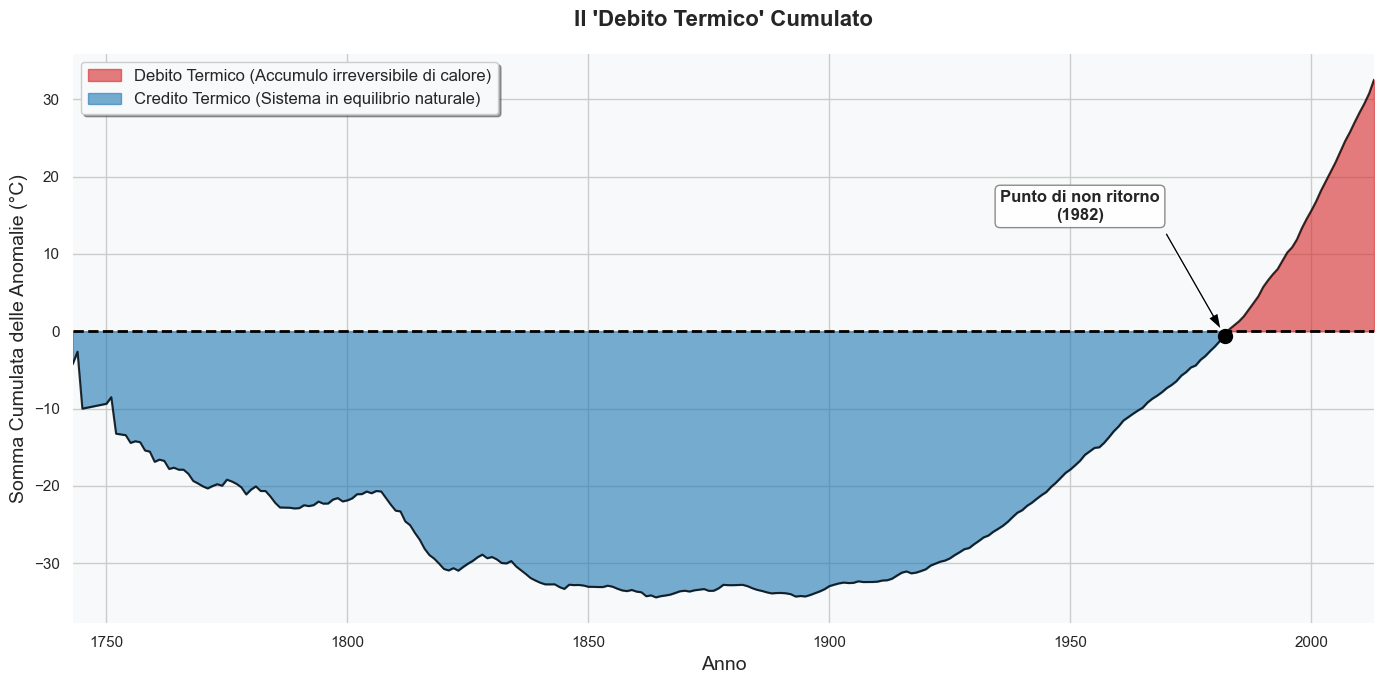

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPARAZIONE DATI E BASELINE (1850-1900)
df_somma_cumulata = uniti.copy()

# Calcoliamo la temperatura "normale" per ogni singola città 
df_baseline = df_somma_cumulata[(df_somma_cumulata['Year'] >= 1850) & (df_somma_cumulata['Year'] <= 1900)]
stats_baseline = df_baseline.groupby('City')['AverageTemperature'].mean().reset_index()
stats_baseline.rename(columns={'AverageTemperature': 'Base_Mean'}, inplace=True)

# Baseline unita al dataset completo
df_calcolo = pd.merge(df_somma_cumulata, stats_baseline, on='City', how='inner')

# 2. CALCOLO DELL'ANOMALIA E DELLA MEDIA GLOBALE ANNUALE
# quanti gradi ogni città si è discostata dalla sua norma in ogni anno
df_calcolo['Anomalia'] = df_calcolo['AverageTemperature'] - df_calcolo['Base_Mean']

# media globale delle anomalie per ogni singolo anno
anomalia_globale = df_calcolo.groupby('Year')['Anomalia'].mean().reset_index()
anomalia_globale = anomalia_globale.sort_values('Year')

# 3.SOMMA CUMULATA (CUSUM)
# Anomalie sommate progressivamente anno dopo anno
anomalia_globale['Anomalia_Cumulata'] = anomalia_globale['Anomalia'].cumsum()


# 4. VISUALIZZAZIONE:
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#f8f9fa"})

anni = anomalia_globale['Year']
somma_cumulata = anomalia_globale['Anomalia_Cumulata']

# blu quando il sistema è in "credito" (si compensa) e di rosso quando è in "debito" (si surriscalda)
plt.fill_between(anni, somma_cumulata, 0, where=(somma_cumulata >= 0), color='#d62728', alpha=0.6, interpolate=True, label='Debito Termico (Accumulo irreversibile di calore)')
plt.fill_between(anni, somma_cumulata, 0, where=(somma_cumulata < 0), color='#1f77b4', alpha=0.6, interpolate=True, label='Credito Termico (Sistema in equilibrio naturale)')

# linea del trend
plt.plot(anni, somma_cumulata, color='black', linewidth=1.5, alpha=0.8)

# 5. INDIVIDUARE IL PUNTO DI NON RITORNO
# l'ultimo anno in cui la somma cumulata era in negativo o vicina allo zero 
# prima dell'impennata finale. In genere avviene intorno agli anni '70/'80.
ultimo_anno_negativo = anomalia_globale[anomalia_globale['Anomalia_Cumulata'] < 0]['Year'].max()

if pd.notna(ultimo_anno_negativo):
    y_punto_rottura = anomalia_globale[anomalia_globale['Year'] == ultimo_anno_negativo]['Anomalia_Cumulata'].values[0]
    
    # punto nero e freccia esplicativa
    plt.scatter([ultimo_anno_negativo], [y_punto_rottura], color='black', s=100, zorder=5)
    plt.annotate(f"Punto di non ritorno\n({int(ultimo_anno_negativo)})", 
                 xy=(ultimo_anno_negativo, y_punto_rottura), 
                 xytext=(ultimo_anno_negativo - 30, y_punto_rottura + 15),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
                 fontsize=12, fontweight='bold', ha='center',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.9))

# Linea dello zero (Equilibrio)
plt.axhline(0, color='black', linewidth=2, linestyle='--', zorder=3)

# Rifiniture estetiche
plt.title("Il 'Debito Termico' Cumulato", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Anno", fontsize=14)
plt.ylabel("Somma Cumulata delle Anomalie (°C)", fontsize=14)

plt.xlim(anomalia_globale['Year'].min(), anomalia_globale['Year'].max())
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

<div class="conclusion-panel" style="border:1px solid #d9e2ec; border-radius:10px; padding:18px 20px; background:#ffffff; box-shadow:0 6px 14px rgba(15, 23, 42, 0.06); max-width:1180px; width:100%; margin:0 auto; font-size:1.03em; line-height:1.5; box-sizing:border-box;">
  <h2 style="margin:0 0 8px 0; color:#111827; font-size:1.28em;">4. Conclusioni</h2>

  <div style="display:grid; grid-template-columns:repeat(auto-fit, minmax(240px, 1fr)); gap:12px;">
    <div style="padding:12px; border-left:4px solid #2563eb; border-radius:8px; background:#fbfdff;">
      <strong>Fasce latitudinali</strong>
      <div>La temperatura non aumenta in modo uniforme. Le fasce polari e temperate registrano incrementi (+1.07°C e +1.06°C/secolo) superiori di circa il 30% rispetto a quelle tropicali (+0.80°C/secolo).
</div>
    </div>
    <div style="padding:12px; border-left:4px solid #0f766e; border-radius:8px; background:#fbfdff;">
      <strong>Stagionalità</strong>
      <div> Si rileva una disomogeneità tra gli emisferi. L'emisfero Nord presenta una progressiva riduzione dell'ampiezza stagionale, assente nell'emisfero Sud.</div>
    </div>
    <div style="padding:12px; border-left:4px solid #d97706; border-radius:8px; background:#fbfdff;">
      <strong>Urbanizzazione</strong>
      <div>Le mediane del trend confermano un aumento più contenuto nelle città piccole/medie, con valori pari a 0.67°C, 0.73°C, 0.80°C e 0.78°C per le quattro classi urbane considerate.</div>
    </div>
    <div style="padding:12px; border-left:4px solid #7c3aed; border-radius:8px; background:#fbfdff;">
      <strong>Punto di non ritorno</strong>
      <div>L'analisi della deviazione dalle medie storiche identifica nel 1982 l'ultimo anno di bilancio termico non positivo; gli anni successivi mostrano un debito termico costante.</div>
    </div>
  </div>
</div>